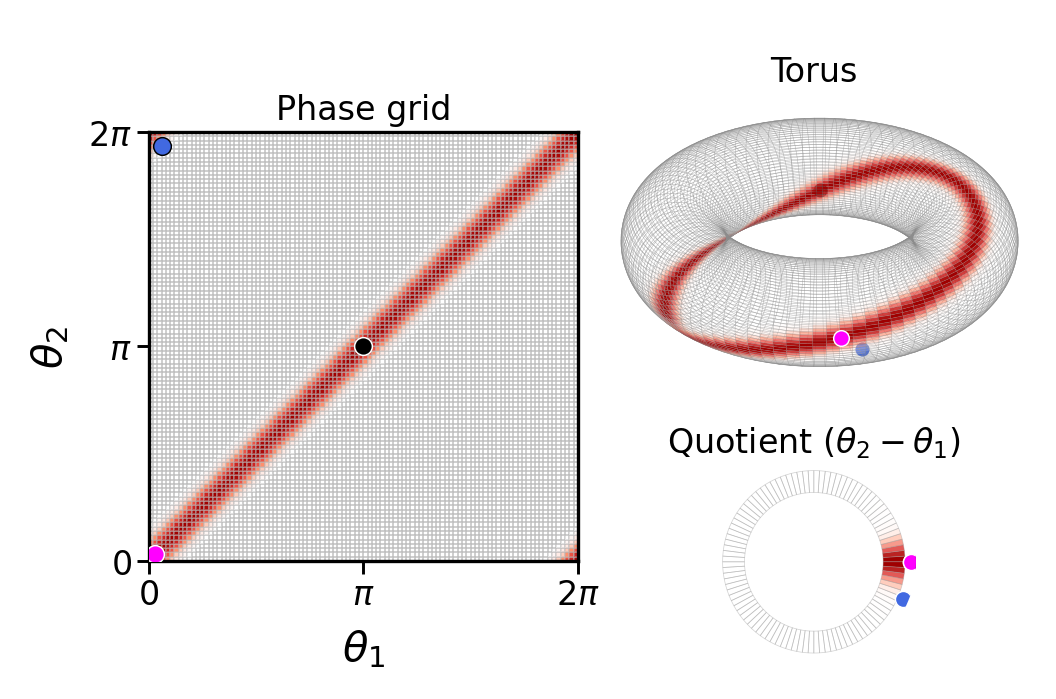

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

# ----------------------------
# Parameters
# ----------------------------
twopi = 2 * np.pi
n = 100

theta1_edges = np.linspace(0, twopi, n + 1)
theta2_edges = np.linspace(0, twopi, n + 1)

theta1 = 0.5 * (theta1_edges[:-1] + theta1_edges[1:])
theta2 = 0.5 * (theta2_edges[:-1] + theta2_edges[1:])
T1, T2 = np.meshgrid(theta1, theta2)

# ----------------------------
# Periodic distance
# ----------------------------
def periodic_diff(a, b, period=2*np.pi):
    return (a - b + period / 2) % period - period / 2

# ----------------------------
# Density on the torus
# ----------------------------
sigma = 0.22

# Main diagonal ridge: theta_2 ≈ theta_1
d_diag = periodic_diff(T2, T1)
density = np.exp(-0.5 * (d_diag / sigma) ** 2)

# # Small hotspot near the periodic corner
# d1 = periodic_diff(T1, 0.28)
# d2 = periodic_diff(T2, twopi - 0.28)
# density += 0.8 * np.exp(-0.5 * ((d1 / 0.20) ** 2 + (d2 / 0.20) ** 2))

density /= density.max()

# Threshold/opacity settings
threshold = 0.07
density_masked = np.ma.masked_where(density < threshold, density)

alpha = np.clip((density - threshold) / (1 - threshold), 0, 1)
alpha = 0.18 + 0.82 * alpha
alpha[density < threshold] = 0.0

# Slightly different white-to-red colormap
white_red = LinearSegmentedColormap.from_list(
    "white_red",
    ["white", "#ffe2d8", "#ff8a65", "#e53935", "#9f0000"]
)

# ----------------------------
# Representative points
# ----------------------------
black_pt = (np.pi, np.pi)
blue_pt = (0.2,2*np.pi-0.2)
magenta_pt = (0.1, 0.1)

# ----------------------------
# Figure layout: heatmap + torus + global-phase quotient
# ----------------------------
fig = plt.figure(figsize=(3.45, 2.55), dpi=300)
gs = GridSpec(
    2, 2,
    width_ratios=[1.0, 1.0],
    height_ratios=[1.35, 0.65],
    wspace=0.05,
    hspace=0.02,
    left=0.13,
    right=0.98,
    bottom=0.12,
    top=0.95
)

# ============================================================
# Left panel: theta_1 / theta_2 density map
# ============================================================
ax = fig.add_subplot(gs[:, 0])

mesh = ax.pcolormesh(
    theta1_edges,
    theta2_edges,
    density_masked,
    cmap=white_red,
    shading="flat",
    edgecolors=(0.72, 0.72, 0.72, 0.42),
    linewidth=0.10,
    antialiased=False
)

# Apply cell-wise opacity
fig.canvas.draw()
facecolors = mesh.get_facecolors()
facecolors[:, -1] = alpha.ravel()
mesh.set_facecolors(facecolors)

# Points
ax.scatter(*black_pt, s=18, c="black", edgecolor="white", linewidth=0.35, zorder=5)
ax.scatter(*blue_pt, s=18, c="royalblue", edgecolor="black", linewidth=0.35, zorder=5)
ax.scatter(
    *magenta_pt,
    s=18,
    marker="o",
    c="magenta",
    edgecolor="white",
    linewidth=0.35,
    zorder=6
)

ax.set_xlim(0, twopi)
ax.set_ylim(0, twopi)
ax.set_aspect("equal")

ax.set_xlabel(r"$\theta_1$", fontsize=10)
ax.set_ylabel(r"$\theta_2$", fontsize=10)

ax.set_xticks([0, np.pi, twopi])
ax.set_xticklabels([r"$0$", r"$\pi$", r"$2\pi$"], fontsize=8)

ax.set_yticks([0, np.pi, twopi])
ax.set_yticklabels([r"$0$", r"$\pi$", r"$2\pi$"], fontsize=8)

ax.tick_params(direction="out", length=3, width=0.7, pad=1)

for spine in ax.spines.values():
    spine.set_linewidth(0.8)

ax.set_title("Phase grid", fontsize=8, pad=3)

# ============================================================
# Right panel: torus with same density
# ============================================================
ax3 = fig.add_subplot(gs[0, 1], projection="3d")

# Torus coordinates
R = 1.0
r = 0.36

U, V = np.meshgrid(theta1, theta2)

X = (R + r * np.cos(V)) * np.cos(U)
Y = (R + r * np.cos(V)) * np.sin(U)
Z = r * np.sin(V)

# Torus camera
view_elev = 30
view_azim = -0

# Close the periodic seams before drawing the 3D surface.
X_plot = np.pad(X, ((0, 1), (0, 1)), mode="wrap")
Y_plot = np.pad(Y, ((0, 1), (0, 1)), mode="wrap")
Z_plot = np.pad(Z, ((0, 1), (0, 1)), mode="wrap")

# Face colors with density-dependent opacity
rgba = white_red(density)
rgba[..., -1] = alpha
rgba_plot = np.pad(rgba, ((0, 1), (0, 1), (0, 0)), mode="wrap")

ax3.plot_surface(
    X_plot, Y_plot, Z_plot,
    facecolors=rgba_plot,
    rstride=1,
    cstride=1,
    linewidth=0.12,
    edgecolor=(0.55, 0.55, 0.55, 0.35),
    antialiased=True,
    shade=False
)

# Map theta points onto the torus
def torus_xyz(theta1, theta2, R=1.0, r=0.36):
    x = (R + r * np.cos(theta2)) * np.cos(theta1)
    y = (R + r * np.cos(theta2)) * np.sin(theta1)
    z = r * np.sin(theta2)
    return x, y, z

# Nudge markers on the visible side slightly toward the camera.
view_elev_rad = np.deg2rad(view_elev)
view_azim_rad = np.deg2rad(view_azim)
camera_dir = np.array([
    np.cos(view_elev_rad) * np.cos(view_azim_rad),
    np.cos(view_elev_rad) * np.sin(view_azim_rad),
    np.sin(view_elev_rad),
])
front_marker_lift = 0.07

for pt, color, marker, size in [
    (black_pt, "black", "o", 14),
    (blue_pt, "royalblue", "o", 14),
    (magenta_pt, "magenta", "o", 14),
]:
    x, y, z = torus_xyz(*pt)
    point_xyz = np.array([x, y, z])
    if np.dot(point_xyz, camera_dir) >= 0:
        x, y, z = point_xyz + front_marker_lift * camera_dir
    ax3.scatter(
        x, y, z,
        s=size,
        c=color,
        marker=marker,
        edgecolor="white",
        linewidth=0.35,
        depthshade=False,
        zorder=10
    )

# Torus appearance
ax3.view_init(elev=view_elev, azim=view_azim)
ax3.set_box_aspect((1, 1, 0.75))
ax3.set_axis_off()
# Place the subtitle against the rendered torus rather than the tall 3D axes box.
ax3.text2D(0.5, 0.9, "Torus", transform=ax3.transAxes,
           ha="center", va="center", fontsize=8)

# Zoom in on torus
lim = 0.9#R + r + front_marker_lift + 0.04
ax3.set_xlim(-lim, lim)
ax3.set_ylim(-lim, lim)
ax3.set_zlim(-0.7, 0.7)

# ============================================================
# Lower-right panel: quotient by the global phase
# T^2 / S^1 is a circle parameterized by phi = theta_2 - theta_1.
# ============================================================
axq = fig.add_subplot(gs[1, 1], projection="polar")

phi_edges = np.linspace(0, twopi, n + 1)
phi = 0.5 * (phi_edges[:-1] + phi_edges[1:])
quotient_density = np.exp(-0.5 * (periodic_diff(phi, 0.0) / sigma) ** 2)
quotient_density /= quotient_density.max()
quotient_alpha = np.clip(
    (quotient_density - threshold) / (1 - threshold), 0, 1
)
quotient_alpha = 0.18 + 0.82 * quotient_alpha
quotient_alpha[quotient_density < threshold] = 0.08

# Draw the quotient circle as a narrow, cell-resolved annulus.
ring = axq.bar(
    phi,
    np.full(n, 0.24),
    width=np.diff(phi_edges),
    bottom=0.76,
    align="center",
    edgecolor=(0.62, 0.62, 0.62, 0.45),
    linewidth=0.18,
)
for patch, value, opacity in zip(ring, quotient_density, quotient_alpha):
    color = white_red(value)
    patch.set_facecolor((*color[:3], opacity))

# Points differing only by global phase coincide on the quotient.
for pt, color, size in [
    (black_pt, "black", 15),
    (blue_pt, "royalblue", 15),
    (magenta_pt, "magenta", 15),
]:
    relative_phase = (pt[1] - pt[0]) % twopi
    axq.scatter(
        relative_phase, 1.06, s=size, c=color,
        edgecolor="white", linewidth=0.35, zorder=10
    )

axq.set_ylim(0, 1.12)
axq.set_xticks([])
axq.set_yticks([])
axq.spines["polar"].set_visible(False)
axq.grid(False)
axq.set_title(r"Quotient ($\theta_2-\theta_1$)", fontsize=8, pad=-1)

# Save
fig.savefig("overview_paper/torus_example.png", bbox_inches="tight", dpi=300)

plt.show()